# Analisis Retail

## Importar Librerias

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df1 = pd.read_excel("online_retail_II.xlsx")
df2 = pd.read_excel("online_retail_II.xlsx", sheet_name="Year 2010-2011")
df = pd.concat([df1, df2], axis=0, ignore_index=True)

In [3]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 65.1+ MB


### Invoice es considerado string, tambien stockcode y descripcion. Luego tambien hay inconcordancias con los valores nulos que debemos de evaluar.


## Comienza la Limpieza

### La idea aqui es que ya vimos que invoice supuestamente deberia ser considerado Int ya que pues solo nos muestra numeros a primera vista, pero no podemos cambiarlo a numero y ya, por lo que el siguiente paso sera ver si sigue algun patron. Explorando un poco vi que los que eran texto tenian una C y justamente Quantity coincidia que era negativo por lo que el siguiente paso sera evaluar ello. Aparte algunos precios figuran como 0, eso no tiene sentido, ¿qué es eso?

In [5]:
df['is_cancellation'] = df['Invoice'].astype(str).str.startswith('C')
df['is_cancellation'].value_counts()

is_cancellation
False    1047877
True       19494
Name: count, dtype: int64

### más de 19 mil registros que supuestamente son negativos, siguiendo con ello, que son esos 0s en price, si supuestamente negativo puede significar devoluciones, ¿por qué hay ceros?

In [6]:
df[df['Price'] <= 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_cancellation
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom,False
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom,False
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom,False
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom,False
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom,False
...,...,...,...,...,...,...,...,...,...
1062442,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom,False
1063965,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,2011-12-08 13:58:00,0.0,NaN,United Kingdom,False
1063966,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,2011-12-08 13:58:00,0.0,NaN,United Kingdom,False
1064015,581408,85175,NaN,20,2011-12-08 14:06:00,0.0,NaN,United Kingdom,False


### Nuevo descubrimiento, los 0 en price no necesariamente es por la compra ni devolucion, no hay costumerID en esos campos, aparte pueden ser negativos como positivos. Son aproximadamente 6mil filas con este hecho, algunos combinan los 3 hechos, costumerID nulo, Desciption nulo y Price en 0

### Conclusión a este punto, esas "ventas" sin precio pueden ser ajustes de inventarios, entonces todavia no nos aporta mucho para el impulso de ventas y el analisis al que estamos llevando a cabo.

In [7]:
df_sin0 = df[df['Price'] > 0].copy()
df_sin0
# la nueva cantidad de filas debe ser la inicial - 6 mil
# Confirmado lo es.

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_cancellation
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False
...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,False
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,False
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,False
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,False


In [8]:
df_sin0.info()

<class 'pandas.DataFrame'>
Index: 1061164 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   Invoice          1061164 non-null  object        
 1   StockCode        1061164 non-null  object        
 2   Description      1061164 non-null  object        
 3   Quantity         1061164 non-null  int64         
 4   InvoiceDate      1061164 non-null  datetime64[us]
 5   Price            1061164 non-null  float64       
 6   Customer ID      824293 non-null   float64       
 7   Country          1061164 non-null  str           
 8   is_cancellation  1061164 non-null  bool          
dtypes: bool(1), datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 73.9+ MB


### Mejora visible, ahora la gran mayoria ya contienen la misma cantidad de no nulos, el principal problema visible es CostumerID, hagamos lo mismo, veamos que patron cumplen si son nulos.

In [9]:
df_sin0[df_sin0['Customer ID'].isnull()]



,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_cancellation
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom,False
578,489525,85227,SET/6 3D KIT CARDS FOR KIDS,1,2009-12-01 11:49:00,0.85,NaN,United Kingdom,False
1055,489548,22271,FELTCRAFT DOLL ROSIE,1,2009-12-01 12:32:00,2.95,NaN,United Kingdom,False
1056,489548,22254,FELT TOADSTOOL LARGE,12,2009-12-01 12:32:00,1.25,NaN,United Kingdom,False
1057,489548,22273,FELTCRAFT DOLL MOLLY,3,2009-12-01 12:32:00,2.95,NaN,United Kingdom,False
...,...,...,...,...,...,...,...,...,...
1066997,581498,85099B,JUMBO BAG RED RETROSPOT,5,2011-12-09 10:26:00,4.13,NaN,United Kingdom,False
1066998,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,2011-12-09 10:26:00,4.13,NaN,United Kingdom,False
1066999,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,2011-12-09 10:26:00,4.96,NaN,United Kingdom,False
1067000,581498,85174,S/4 CACTI CANDLES,1,2011-12-09 10:26:00,10.79,NaN,United Kingdom,False


### No siguen ningun patron, por lo que es muy probable que sean errores de carga de datos.
### Son como 236 mil filas con este patron, la gravedad de esto es muy alta, 1 de cada 4 son nulas.
### No es recomendable eliminar todas estas filas, ya que se perderia mucha informacion. Por otro lado al ser algo tan comun, ¿qué tanto de esto se hace dia a dia?

In [10]:
df_sin0["InvoiceMonth"] = df_sin0["InvoiceDate"].dt.to_period('M')
df_sin0.groupby("InvoiceMonth")["Customer ID"].apply(lambda x: x.isnull().mean()*100)

InvoiceMonth
2009-12    29.393845
2010-01    28.374409
2010-02    17.163946
2010-03    19.644244
2010-04    17.891072
2010-05    14.877221
2010-06    19.514776
2010-07    16.523754
2010-08    18.474248
2010-09    15.596002
2010-10    14.070839
2010-11    20.824641
2010-12    35.480923
2011-01    37.415374
2011-02    26.171139
2011-03    23.784998
2011-04    21.780475
2011-05    21.419057
2011-06    24.127780
2011-07    30.078820
2011-08    21.322295
2011-09    18.467623
2011-10    16.217110
2011-11    22.335248
2011-12    30.661118
Freq: M, Name: Customer ID, dtype: float64

### Es un problema de cada mes entonces, aproximadamente de 15% hasta un maximo de 35% de nulos en un solo mes, es preocupante encontrar eso. Hay una pequeña probabilidad que asi funcione el negocio, en el día a día hay algunas empresas que manejan ello como "Cliente anonimo".

In [11]:
df_sin0["TotalPrice"] = df_sin0["Price"] * df_sin0["Quantity"]
cliente = df_sin0[df_sin0['Customer ID'].notnull()]["TotalPrice"]
sincliente = df_sin0[df_sin0['Customer ID'].isnull()]["TotalPrice"]
print("Promedio de ventas con cliente: ", cliente.mean())
print("Promedio de ventas sin cliente: ", sincliente.mean())

Promedio de ventas con cliente:  20.19705661457758
Promedio de ventas sin cliente:  11.810792878824339


### Primera impresión: los que no son nulos suelen hacer compras más fuertes, sin embargo los que son nulos suelen hacer compras pequeñas. Esto puede ser parte del negocio para compras rapidas.
### Conclusión de este punto, estos nulos no son errores son parte del negocio para compras rápidas.

In [12]:
totcancel_nnull= df_sin0[(df_sin0["is_cancellation"]==False) & (df_sin0["Customer ID"].notnull())]["TotalPrice"].sum().round(2)
totcancel_null= df_sin0[(df_sin0["is_cancellation"]==False) & (df_sin0["Customer ID"].isnull())]["TotalPrice"].sum().round(2)
print(totcancel_nnull, totcancel_null, totcancel_nnull+totcancel_null)
print("que parte de las ventas viene de clientes sin identificar: ", (totcancel_null/(totcancel_nnull+totcancel_null)*100).round(2), "% (antes de quitar duplicados)")

17743429.18 3229165.39 20972594.57
que parte de las ventas viene de clientes sin identificar:  15.4 % (antes de quitar duplicados)


### Ahora ya sabemos que gran mayoria de ganancias provienen de clientes identificados, el 15% de nuestras ganancias provienen de clientes anonimos un numero relativamente bajo pero que tampoco se puede dejar a un lado, por lo que si debemos priorizar a los clientes identificados.

## Posibles duplicados

In [13]:
print(df_sin0.duplicated().sum(),"///",df_sin0.duplicated().mean()*100)
#¿Que son estos duplicados?

34147 /// 3.2178814961683586


In [14]:
dup = df_sin0[df_sin0.duplicated(keep=False)].sort_values(['Invoice', 'StockCode'])
dup

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_cancellation,InvoiceMonth,TotalPrice
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom,False,2009-12,1.95
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom,False,2009-12,1.95
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,False,2009-12,3.75
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,False,2009-12,3.75
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,False,2009-12,3.75
...,...,...,...,...,...,...,...,...,...,...,...
965610,C574510,22360,GLASS JAR ENGLISH CONFECTIONERY,-1,2011-11-04 13:25:00,2.95,15110.0,United Kingdom,True,2011-11,-2.95
986868,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,2011-11-13 11:38:00,0.55,17838.0,United Kingdom,True,2011-11,-13.20
986869,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,2011-11-13 11:38:00,0.55,17838.0,United Kingdom,True,2011-11,-13.20
1055441,C580764,22667,RECIPE BOX RETROSPOT,-12,2011-12-06 10:38:00,2.95,14562.0,United Kingdom,True,2011-12,-35.40


### La primera noción de esto es que si o si son duplicados por errores del sistema, se hacen a la misma hora, misma cantida, mismo producto, etc.La primera idea era que posiblemente el mismo cliente quizo el mismo producto pero seria muy difícil que se registre a la misma hora. 
### Descubrimiento aun peor, las cancelaciones se duplican, esto solo significa descuadre de inventarios.

In [15]:
dup.groupby(['Invoice', 'StockCode']).size().value_counts()



2     31236
4       568
3       522
6        66
5        12
8         5
10        3
12        1
20        1
Name: count, dtype: int64

### Estos duplicados si son realmente un error,¿por qué? es muy dificil que una misma venta se realice 20 veces al mismo tiempo, quizá al ser mayorista puede que en algun punto se haya registrado la venta uno por uno pero dificilmente se hace a la misma hora, a su vez son 31 mil duplicados, a su vez sabemos que esto representa el 3% de las ventas por lo que no es necesariamente un valor muy significativo.

In [16]:
df_sin0.drop_duplicates(inplace=True)
df_clean = df_sin0.copy()
df_clean

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_cancellation,InvoiceMonth,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,2009-12,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,2009-12,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,2009-12,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False,2009-12,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,2009-12,30.00
...,...,...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,False,2011-12,12.60
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,False,2011-12,16.60
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,False,2011-12,16.60
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,False,2011-12,14.85


In [17]:
df_clean.info()
df_clean.to_csv('retail_clean.csv', index=False)

<class 'pandas.DataFrame'>
Index: 1027017 entries, 0 to 1067370
Data columns (total 11 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   Invoice          1027017 non-null  object        
 1   StockCode        1027017 non-null  object        
 2   Description      1027017 non-null  object        
 3   Quantity         1027017 non-null  int64         
 4   InvoiceDate      1027017 non-null  datetime64[us]
 5   Price            1027017 non-null  float64       
 6   Customer ID      797815 non-null   float64       
 7   Country          1027017 non-null  str           
 8   is_cancellation  1027017 non-null  bool          
 9   InvoiceMonth     1027017 non-null  period[M]     
 10  TotalPrice       1027017 non-null  float64       
dtypes: bool(1), datetime64[us](1), float64(3), int64(1), object(3), period[M](1), str(1)
memory usage: 87.2+ MB


### Ahora que ya quitamos los duplicados, vuelvo a calcular el porcentaje de ingreso sin cliente identificado. El de arriba estaba sobre datos que todavía tenían las 34 mil filas repetidas, así que este es el número bueno, el que va al README.

In [18]:
con_cliente = df_clean[(df_clean["is_cancellation"]==False) & (df_clean["Customer ID"].notnull())]["TotalPrice"].sum()
sin_cliente = df_clean[(df_clean["is_cancellation"]==False) & (df_clean["Customer ID"].isnull())]["TotalPrice"].sum()
print("Ingreso con cliente identificado: ", round(con_cliente, 2))
print("Ingreso sin cliente identificado: ", round(sin_cliente, 2))
print("Porcentaje sin identificar: ", round(sin_cliente/(con_cliente+sin_cliente)*100, 2), "%")

Ingreso con cliente identificado:  17374804.27
Ingreso sin cliente identificado:  3101456.18
Porcentaje sin identificar:  15.15 %


## Finalmente la limpieza ha terminado

## Analisis ahora si

In [19]:
df_clean[['Quantity',"Price","TotalPrice"]].describe().round(3)

,Quantity,Price,TotalPrice
count,1027017.000,1027017.000,1027017.000
mean,10.446,4.796,18.514
std,168.634,93.108,285.548
min,-80995.000,0.001,-168469.600
25%,1.000,1.250,3.750
50%,3.000,2.100,9.950
75%,10.000,4.150,17.700
max,80995.000,38970.000,168469.600


### Quantity tiene el mismo numero en min y max pero con diferente signo.

In [20]:
df_clean[df_clean['Quantity'].abs() == 80995]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_cancellation,InvoiceMonth,TotalPrice
1065882,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,False,2011-12,168469.6
1065883,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom,True,2011-12,-168469.6


### No es duplicado. pues compra a las 9 y 15, para posteriormente al as 9 y 27 devolverlo, probablemente el cliente hizo un encargo y no era lo que le mandaron o etc.

<Axes: xlabel='TotalPrice', ylabel='Count'>

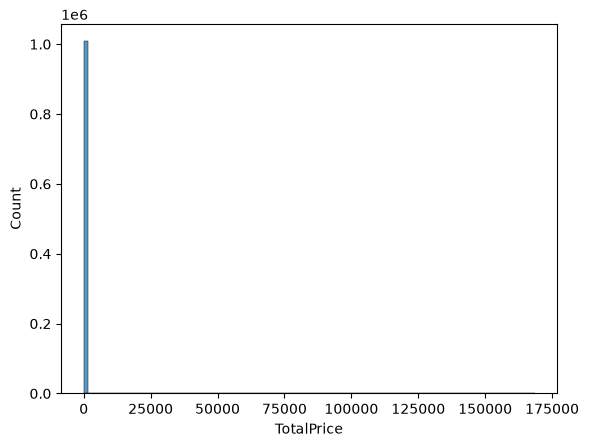

In [21]:
sns.histplot(df_clean[df_clean['is_cancellation'] == False]['TotalPrice'], bins=100)


<Axes: xlabel='TotalPrice', ylabel='Count'>

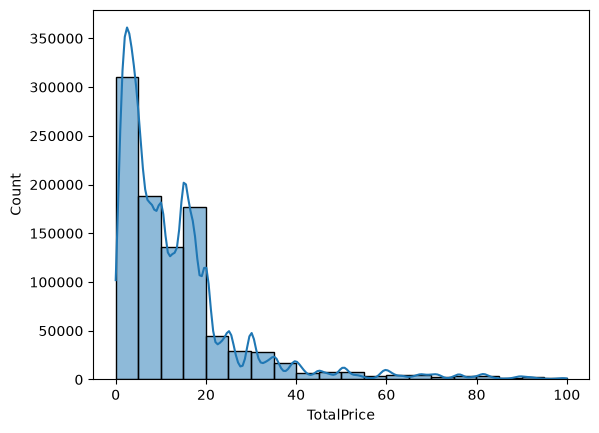

In [22]:
#Interesante
sns.histplot(df_clean[(df_clean['TotalPrice'] >0) & (df_clean['TotalPrice'] <100)]['TotalPrice'], bins=20,kde=True)


### Nuevo descubrimiento, existe sesgo en el lado derecho, solo si tomamos las ventas sin devolucion, que es lo que nos interesa, luego se procedera con las negativas para ver que patron siguen las devoluciones.
### Las personas tienden a hacer compras pequeñas de 40 a 0,... dolares, entonces el primer punto es que las personas no suelen hacer compras por mayoreo pero si hay alguna que otra pequeña excepcion.

<Axes: xlabel='TotalPrice', ylabel='Count'>

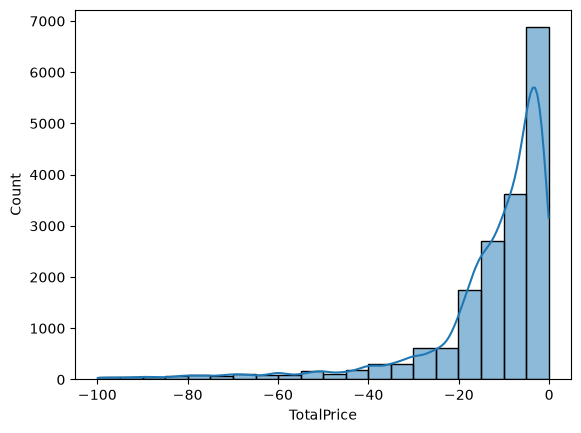

In [23]:
sns.histplot(df_clean[(df_clean['TotalPrice'] <0) & (df_clean['TotalPrice'] >-100)]['TotalPrice'], bins=20,kde=True)

### De el mismo modo las personas suelen hacer devoluciones de productos pequeños aproximadamente de 40 a 0,... dolares, por lo que la idea es clara, la venta al por menor lidera esta tienda, probablemente si sacamos más ofertas al por menor podriamos aumentar las ventas.

In [24]:
print(df_clean["TotalPrice"].skew())
print(df_clean[df_clean['is_cancellation']==False]['TotalPrice'].skew())
print(df_clean[df_clean['is_cancellation']==True]['TotalPrice'].skew())


-1.0723526819010654
608.6145501246691
-89.44635383119073


### Supuestamente hay sesgo a la izquierda. Esto nos da mucho que analizar, si tomamos solo ventas nos da 600 entonces eso significa que hay sesgo a la derecha, si tomamos solo devoluciones, ese -89 significa que hay sesgo a la izquierda , en conclusion nuestra grafica en general se veria muy estirada con dos picos que hacen que nuestra grafica se haga muy grande.Todo gracias a valores muy grandes que existen en nuestros datos.

<Axes: xlabel='InvoiceMonth'>

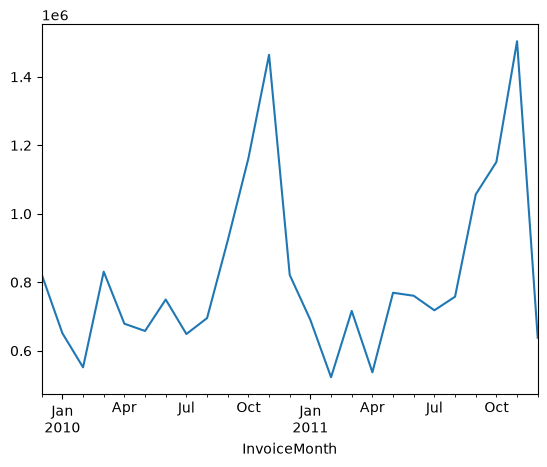

In [25]:
df_clean[df_clean['is_cancellation']==False].groupby('InvoiceMonth')['TotalPrice'].sum().plot(kind='line')


### Existe un patron, al parecer desde septiembre hasta noviembre en ambos años empiezan a haber altas ventas, por ello empiezan a haber picos muy altos. Lo más prudente seria hacer más ofertas en estos días.

<Axes: title={'center': 'Top 10 productos por ventas totales (sin cargos de servicio)'}, ylabel='Description'>

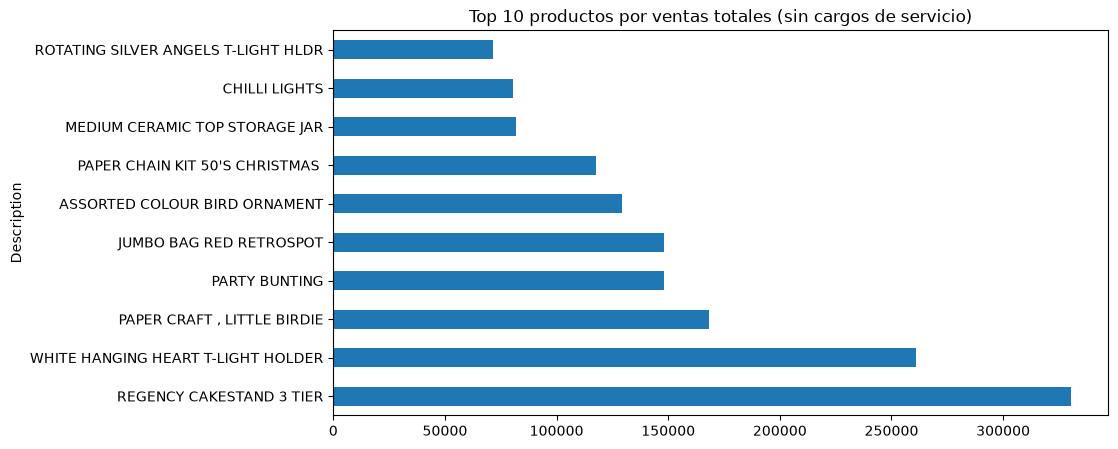

In [26]:
# M, POST, DOT y BANK CHARGES no son mercaderia: son cargos manuales, envio y comisiones.
servicios = ['M', 'POST', 'DOT', 'BANK CHARGES', 'C2', 'AMAZONFEE']
productos = df_clean[(df_clean['is_cancellation']==False) & (~df_clean['StockCode'].isin(servicios))]

productos.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10).plot(
    kind='barh', figsize=(10,5), title="Top 10 productos por ventas totales (sin cargos de servicio)")

### Al principio el primer puesto lo tenía "Manual", que no es un producto sino una boleta cargada a mano con el total agrupado. Igual pasaba con POSTAGE, que es el cobro del envío. Los saqué junto con los otros códigos de servicio, y recién ahí el ranking muestra mercadería de verdad. Es un detalle chico pero cambia la lectura: si no lo filtras, el producto estrella de la tienda resulta ser un cargo administrativo.

<Axes: xlabel='Country'>

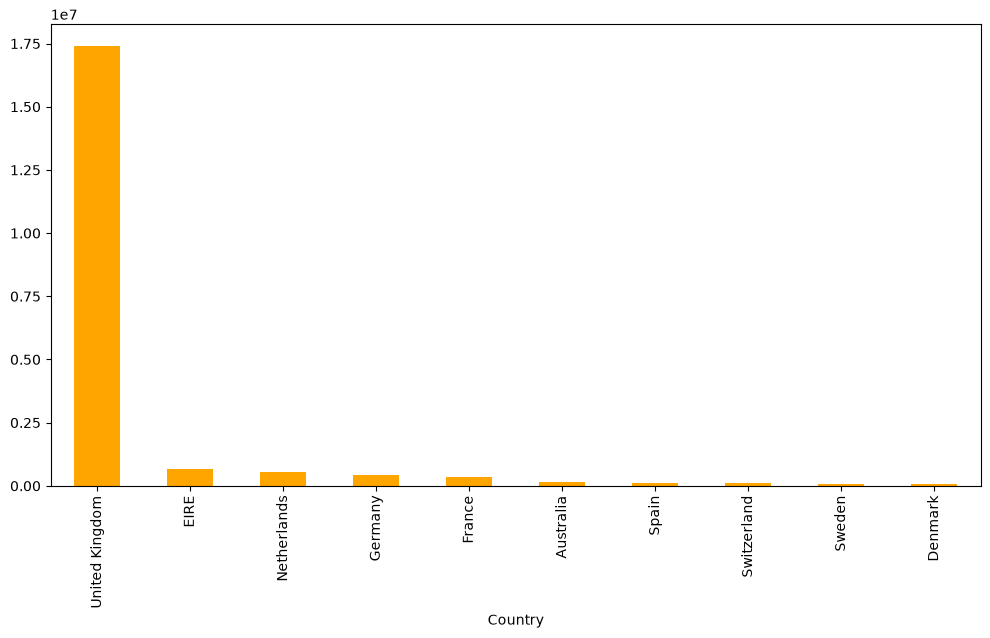

In [27]:
df_clean[df_clean['is_cancellation']==False].groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10).plot(kind='bar', figsize=(12,6), color='orange')

### UK Domina nuestro mercado es por ello que es de los que más concideración debería de tener, por otro lado existen varios factores que afectan esto, quizá más tiendas en este país, más tiempo en ese mercado, etc. Sin embargo ya una vez instalado en este país no habría porque dejar ir este mercado o no innovar en otros paises.

<Axes: title={'center': 'Top 10 países con mayor porcentaje de cancelaciones'}, xlabel='Country'>

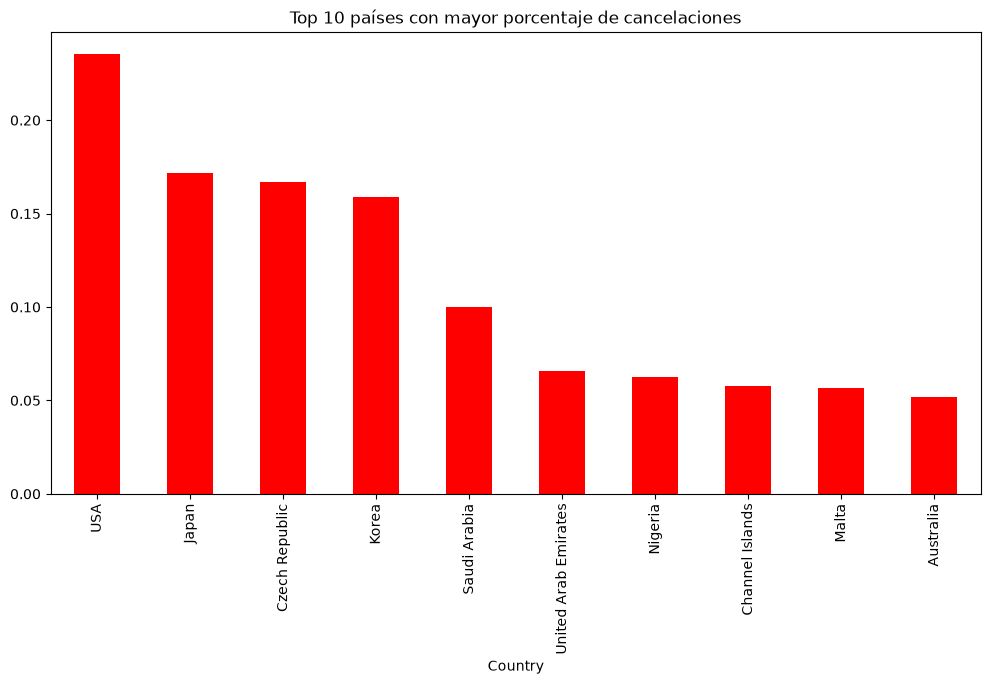

In [28]:
df_clean.groupby('Country')['is_cancellation'].mean().sort_values(ascending=False).head(10).plot(kind='bar', figsize=(12,6), color='red', title="Top 10 países con mayor porcentaje de cancelaciones")

### Aproximadamente en estados unidos es donde más devoluciones existen, entonces debemos de tener más cuidado en este país, sin descuidar los demás. La principal solución puede ser hacer más auditorias, por otro lado también verificar como se muestra la mercadera el cuidado que se tiene aya. Debido a que probablemente las devoluciones sea porque el producto le llego roto/golpeado.

<Axes: title={'center': 'Tasa de cancelación por país (mín. 100 pedidos)'}, ylabel='Country'>

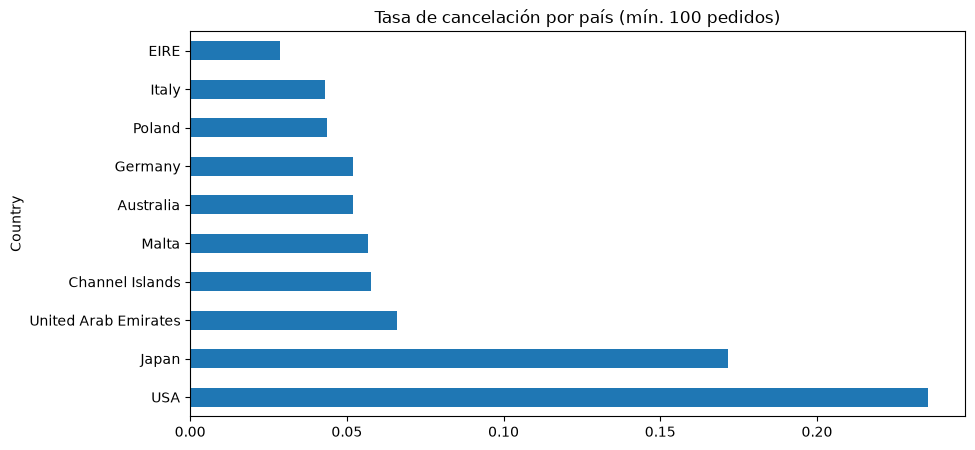

In [29]:
counts = df_clean.groupby('Country').size()
paises_confiables = counts[counts >= 100].index

df_clean[df_clean['Country'].isin(paises_confiables)].groupby('Country')['is_cancellation'].mean().sort_values(ascending=False).head(10).plot(kind='barh', figsize=(10,5), title="Tasa de cancelación por país (mín. 100 pedidos)")


### Casi que el mismo resultado pero sin tanto ruido estadístico, Japón y USa siguens siendo prioridad, pero UAE y la gran mayoria se han sumado por lo que ahora ya tenemos más claro el panorama.

## Ahora si seguimiento al cliente(RFM=Recency, Frequency, Monetary )

### Clientes que conocemos

In [30]:
df_rfm = df_clean[(df_clean["is_cancellation"]==False) & (df_clean["Customer ID"].notnull())]
df_rfm

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_cancellation,InvoiceMonth,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,2009-12,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,2009-12,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,2009-12,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False,2009-12,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,2009-12,30.00
...,...,...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,False,2011-12,12.60
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,False,2011-12,16.60
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,False,2011-12,16.60
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,False,2011-12,14.85


In [31]:
#Primero Recency
fecha_referencia = df_rfm['InvoiceDate'].max() + pd.Timedelta(days=1)
recency = df_rfm.groupby('Customer ID')['InvoiceDate'].max().apply(lambda x: (fecha_referencia - x).days)
recency

Customer ID
12346.0    326
12347.0      2
12348.0     75
12349.0     19
12350.0    310
          ... 
18283.0      4
18284.0    432
18285.0    661
18286.0    477
18287.0     43
Name: InvoiceDate, Length: 5878, dtype: int64

In [32]:
recency.describe()

count    5878.000000
mean      201.331916
std       209.338707
min         1.000000
25%        26.000000
50%        96.000000
75%       380.000000
max       739.000000
Name: InvoiceDate, dtype: float64

In [33]:
#Frequency
frequency = df_rfm.groupby('Customer ID')['Invoice'].nunique()
frequency.describe()

count    5878.000000
mean        6.289384
std        13.009406
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       398.000000
Name: Invoice, dtype: float64

In [34]:
#Monetary
monetary = df_rfm.groupby('Customer ID')['TotalPrice'].sum()
monetary.describe()

count      5878.000000
mean       2955.904095
std       14440.852688
min           2.950000
25%         342.280000
50%         867.740000
75%        2248.305000
max      580987.040000
Name: TotalPrice, dtype: float64

In [35]:
rfm = pd.DataFrame({'Recency': recency, 'Frequency': frequency, 'Monetary': monetary})

rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5]).astype(int)

rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']


In [36]:
rfm.head()


,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
Customer ID,,,,,,,
12346.0,326,12,77556.46,2,5,5,12
12347.0,2,8,4921.53,5,4,5,14
12348.0,75,5,2019.40,3,4,4,11
12349.0,19,4,4428.69,5,3,5,13
12350.0,310,1,334.40,2,1,2,5


In [37]:
rfm['RFM_score'].describe()

count    5878.000000
mean        9.005104
std         3.643923
min         3.000000
25%         6.000000
50%         9.000000
75%        12.000000
max        15.000000
Name: RFM_score, dtype: float64

In [38]:
# El orden importa: np.select se queda con la PRIMERA condicion que se cumple.
# "En riesgo" va antes que "Leales" porque es la mas especifica; si va despues,
# los clientes que compraban mucho y dejaron de venir caen en "Leales".
condiciones = [
    (rfm['R_score'] >= 4) & (rfm['F_score'] >= 4),
    (rfm['R_score'] <= 2) & (rfm['F_score'] >= 3),
    (rfm['F_score'] >= 4) & (rfm['R_score'] < 4),
    (rfm['R_score'] <= 2) & (rfm['F_score'] <= 2),
]
segmentos = ['Campeones', 'En riesgo', 'Leales', 'Perdidos']

rfm['Segmento'] = np.select(condiciones, segmentos, default='Regulares')
rfm['Segmento'].value_counts()

Segmento
Regulares    1533
Perdidos     1523
Campeones    1482
En riesgo     824
Leales        516
Name: count, dtype: int64

### Qué dice cada segmento

**Campeones (1,482 clientes).** Compran seguido y compraron hace poco: mediana de 17 días desde la última compra y 10 facturas cada uno. Son el 25% de los clientes identificados y generan el 69% del ingreso. El negocio depende de ellos, y esa concentración es también el riesgo.

**En riesgo (824 clientes).** Compraban seguido y dejaron de venir: mediana de 374 días sin comprar, pero con 4 facturas y 1,024 gastados por cliente en su momento. Ya demostraron que la tienda les servía, así que reactivarlos cuesta menos que conseguir un cliente nuevo.

**Leales (516 clientes).** Compran seguido y siguen activos, aunque no tan recientes como los Campeones: mediana de 95 días. Es el grupo que puede subir a Campeones si se le da una razón para volver antes.

**Regulares (1,533) y Perdidos (1,523).** Entre los dos son más de la mitad de los clientes pero apenas el 12% del ingreso. Los Perdidos tienen mediana de una sola compra y 435 días de ausencia: fueron compras de una vez, y perseguirlos sale más caro de lo que devuelven.

### La conclusión

La prioridad no es el segmento más grande sino el que más se puede mover: **Campeones se cuida, En riesgo se reactiva, Perdidos se deja ir.**

In [39]:
rfm.groupby('Segmento')['Monetary'].sum().sort_values(ascending=False) / rfm['Monetary'].sum() * 100

Segmento
Campeones    69.205557
Leales        9.737827
En riesgo     9.147639
Regulares     8.142450
Perdidos      3.766527
Name: Monetary, dtype: float64

### Guardo la tabla RFM para la siguiente etapa, la de SQL y el dashboard. El índice es el Customer ID, así que va incluido.

In [40]:
rfm.to_csv('retail_rfm.csv', index=True)
print("Guardado retail_rfm.csv con", len(rfm), "clientes")

Guardado retail_rfm.csv con 5878 clientes


### Con esto termina la primera etapa del análisis. Arranqué con 1,067,371 filas bastante sucias — cancelaciones mezcladas con ventas, precios en cero, duplicados por el solape de las dos hojas del Excel — y terminé con 1,027,017 filas limpias, documentadas paso a paso.

### Lo que más me sorprendió: un 15.15% de todo el ingreso viene de clientes que ni siquiera están identificados. No es un error de los datos, es que compran rápido sin registrarse, y pasa todos los meses por igual, no en fechas puntuales. Después está lo más esperable pero ya confirmado con números reales: Reino Unido es el 85% del negocio, y noviembre es por lejos el mejor mes.

### Lo que más me sirvió para pensar en negocio fue el RFM: 1 de cada 4 clientes identificados ("Campeones") genera casi el 70% del ingreso. Y hay 824 clientes "En riesgo" que compraban seguido y llevan una mediana de 374 días sin volver — esos son los que más conviene tratar de recuperar, porque ya demostraron que compran.

### El error que casi se me pasa: al segmentar con np.select, el orden de las condiciones es la lógica, porque gana la primera que se cumple. Tenía "Leales" antes que "En riesgo" y eso mandaba 353 clientes al segmento equivocado — justo los que quería recuperar. No daba error, solo etiquetaba mal. La regla que me llevo: la condición más específica va primero, y siempre revisar los números, no solo que el código corra.